In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
import shap
shap.initjs()

/home/drake/my-venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
df = pd.read_csv("Census_Income.csv")
df.head()

,AGE,WORKCLASS,EDUCATION,EDUCATION_NUM,MARITAL_STATUS,OCCUPATION,RELATIONSHIP,RACE,SEX,HOURS_PER_WEEK,NATIONALITY,INCOME
0,39,State-gov,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,40,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,13,United-States,<=50K
2,38,Private,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,40,United-States,<=50K
3,53,Private,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,40,United-States,<=50K
4,28,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,40,Cuba,<=50K


In [7]:
numeric_cols = df.select_dtypes(include=['number'])
scaler = StandardScaler()
df[numeric_cols.columns] = scaler.fit_transform(numeric_cols)
df.head()

,AGE,WORKCLASS,EDUCATION,EDUCATION_NUM,MARITAL_STATUS,OCCUPATION,RELATIONSHIP,RACE,SEX,HOURS_PER_WEEK,NATIONALITY,INCOME
0,0.030671,State-gov,Bachelors,1.134739,Never-married,Adm-clerical,Not-in-family,White,Male,-0.035429,United-States,<=50K
1,0.837109,Self-emp-not-inc,Bachelors,1.134739,Married-civ-spouse,Exec-managerial,Husband,White,Male,-2.222153,United-States,<=50K
2,-0.042642,Private,HS-grad,-0.420060,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.035429,United-States,<=50K
3,1.057047,Private,11th,-1.197459,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.035429,United-States,<=50K
4,-0.775768,Private,Bachelors,1.134739,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.035429,Cuba,<=50K


In [8]:
cat_cols = [1,2,4,5,6,7,8,10]
df_encoded = pd.get_dummies(df, columns=df.columns[cat_cols]) 
df.head()

,AGE,WORKCLASS,EDUCATION,EDUCATION_NUM,MARITAL_STATUS,OCCUPATION,RELATIONSHIP,RACE,SEX,HOURS_PER_WEEK,NATIONALITY,INCOME
0,0.030671,State-gov,Bachelors,1.134739,Never-married,Adm-clerical,Not-in-family,White,Male,-0.035429,United-States,<=50K
1,0.837109,Self-emp-not-inc,Bachelors,1.134739,Married-civ-spouse,Exec-managerial,Husband,White,Male,-2.222153,United-States,<=50K
2,-0.042642,Private,HS-grad,-0.420060,Divorced,Handlers-cleaners,Not-in-family,White,Male,-0.035429,United-States,<=50K
3,1.057047,Private,11th,-1.197459,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,-0.035429,United-States,<=50K
4,-0.775768,Private,Bachelors,1.134739,Married-civ-spouse,Prof-specialty,Wife,Black,Female,-0.035429,Cuba,<=50K


In [9]:
le = LabelEncoder()
df_encoded['INCOME'] = le.fit_transform(df['INCOME'])
df_encoded.head()

,AGE,EDUCATION_NUM,HOURS_PER_WEEK,INCOME,WORKCLASS_ ?,WORKCLASS_ Federal-gov,WORKCLASS_ Local-gov,WORKCLASS_ Never-worked,WORKCLASS_ Private,WORKCLASS_ Self-emp-inc,...,NATIONALITY_ Portugal,NATIONALITY_ Puerto-Rico,NATIONALITY_ Scotland,NATIONALITY_ South,NATIONALITY_ Taiwan,NATIONALITY_ Thailand,NATIONALITY_ Trinadad&Tobago,NATIONALITY_ United-States,NATIONALITY_ Vietnam,NATIONALITY_ Yugoslavia
0,0.030671,1.134739,-0.035429,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,0.837109,1.134739,-2.222153,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,-0.042642,-0.420060,-0.035429,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
3,1.057047,-1.197459,-0.035429,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
4,-0.775768,1.134739,-0.035429,0,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [10]:
y = df_encoded['INCOME']
df_encoded.drop(columns=['INCOME'],inplace=True)
X = df_encoded

In [11]:
LR_model = LogisticRegression(C=0.205, max_iter=300, random_state=42, solver='newton-cg').fit(X,y)

In [12]:
coefficients = LR_model.coef_[0]

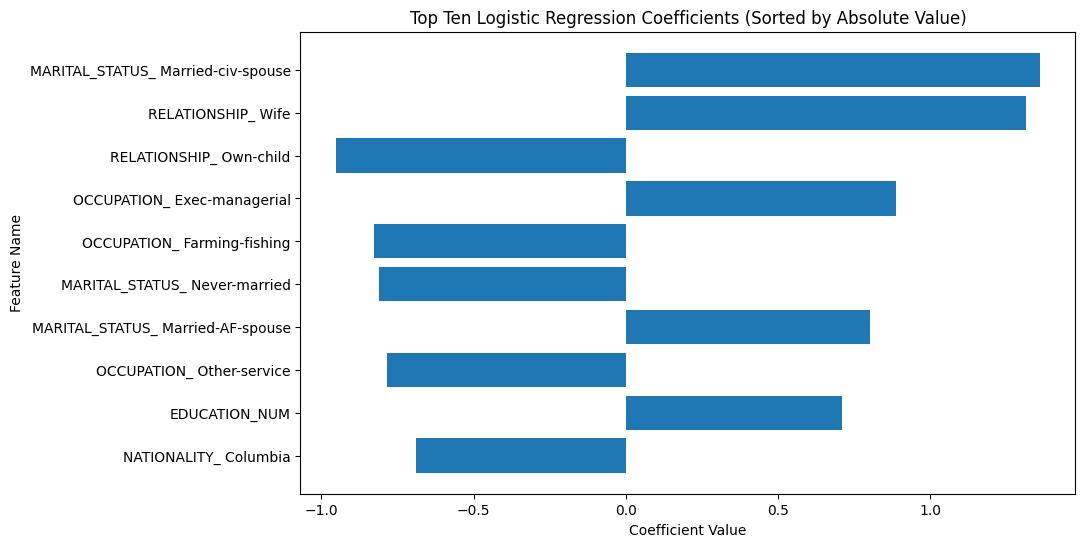

In [13]:
feature_names = list(X.columns)
coef_feature_pairs = list(zip(coefficients, feature_names))
sorted_coef_feature_pairs = sorted(coef_feature_pairs, key=lambda x: abs(x[0]), 
reverse=True)
sorted_coefficients, sorted_feature_names = zip(*sorted_coef_feature_pairs)
top_ten_coefficients = sorted_coefficients[:10]
top_ten_feature_names = sorted_feature_names[:10]

plt.figure(figsize=(10, 6))
plt.barh(top_ten_feature_names, top_ten_coefficients)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature Name')
plt.title('Top Ten Logistic Regression Coefficients (Sorted by Absolute Value)')
plt.gca().invert_yaxis() 
plt.show()

In [14]:
RF_model = RandomForestClassifier(n_estimators=100, max_depth=40, max_features='sqrt', min_samples_split=2, min_samples_leaf=2, criterion='entropy', class_weight=None, bootstrap=True).fit(X,y)

In [15]:
importances = RF_model.feature_importances_

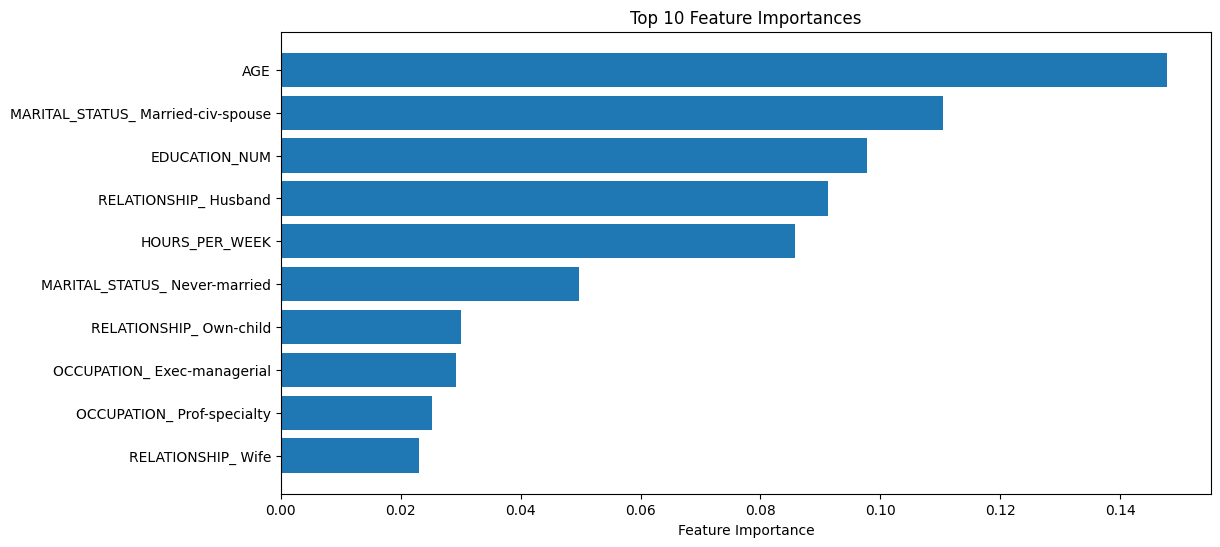

In [16]:
feature_importance_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', 
ascending=False)
top_n = 10   

plt.figure(figsize=(12, 6))
plt.barh(range(top_n), feature_importance_df['Importance'][:top_n], align='center')
plt.yticks(range(top_n), feature_importance_df['Feature'][:top_n])
plt.xlabel('Feature Importance')
plt.title('Top {} Feature Importances'.format(top_n))
plt.gca().invert_yaxis()  
plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [18]:
NN_model = MLPClassifier(alpha=0.06, hidden_layer_sizes=(50, 50), learning_rate_init=0.03, max_iter=158).fit(X_train, y_train)

In [19]:
perm_importance = permutation_importance(NN_model, X_test, y_test, n_repeats=10, random_state=42)

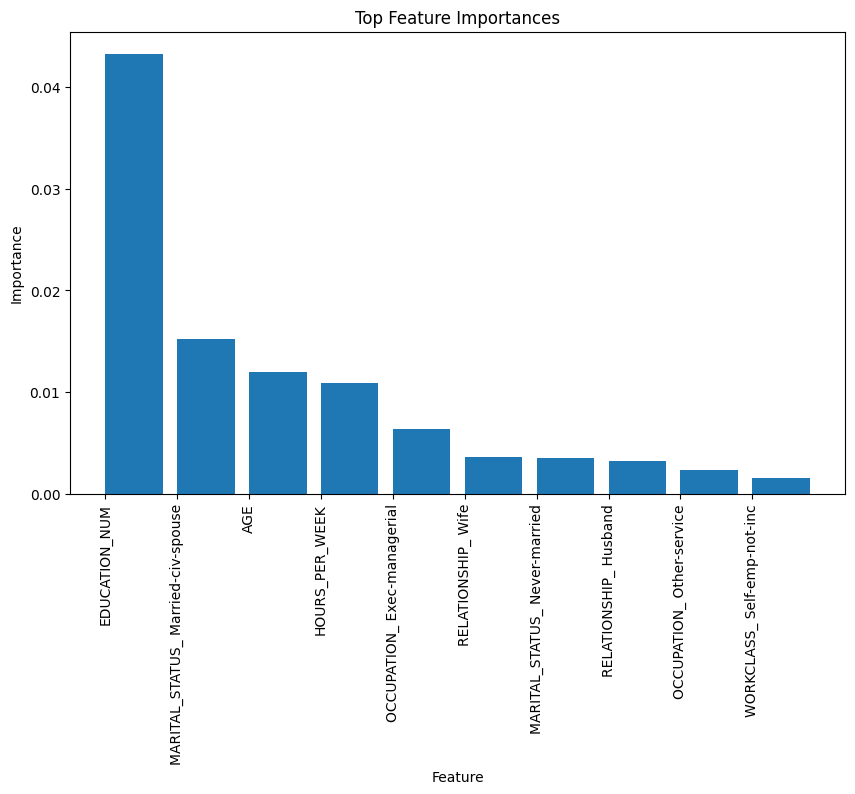

In [20]:
feature_importances = perm_importance.importances_mean
sorted_idx = feature_importances.argsort()[::-1]
feature_names = X.columns
top_n = 10

plt.figure(figsize=(10, 6))
plt.bar(range(top_n), feature_importances[sorted_idx[:top_n]], align="edge")
plt.xticks(range(top_n), [feature_names[i] for i in sorted_idx[:top_n]], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Top Feature Importances")
plt.show()

In [21]:
explainer = shap.Explainer(RF_model)

In [23]:
shap_values = explainer(X[:100])

In [24]:
RF_model.predict_proba(X)[0]

array([0.91938085, 0.08061915])

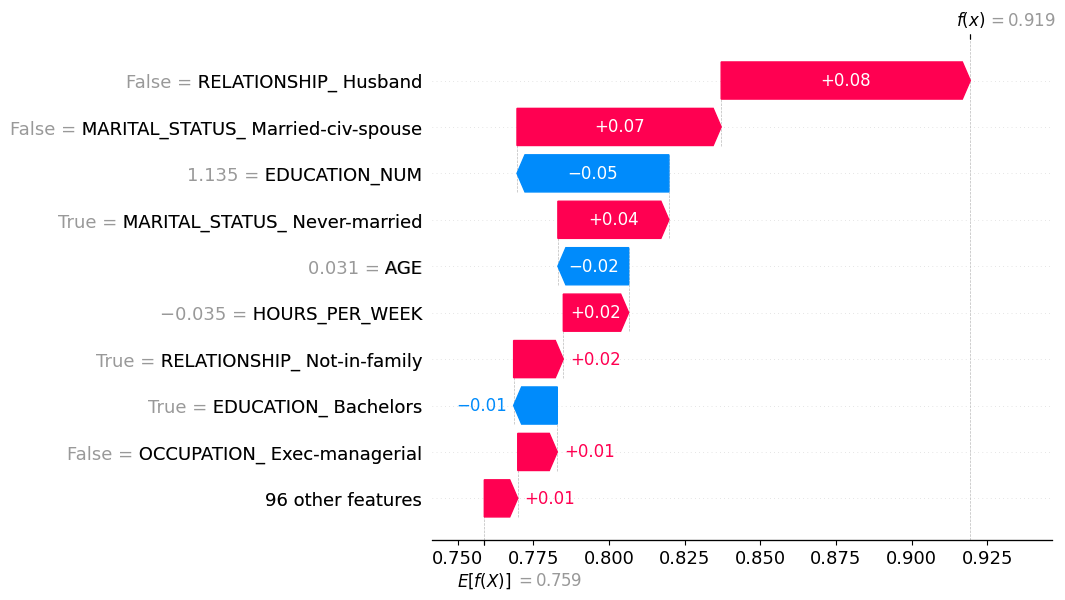

In [25]:
shap.plots.waterfall(shap_values[0,:,0])